<a href="https://colab.research.google.com/github/A-Vineela/IIIT-H-Summer-School-2026/blob/main/Reasoning_CVIT_SSAI_2026_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reasoning in Language Models

**Learning objectives.**
1. Understand chain-of-thought, self-consistency, tree-of-thought, and least-to-most prompting as different ways of turning one hard inference into several easier, structured ones.
2. Understand verifier-guided decoding (Best-of-N) and the process-vs-outcome reward distinction that underlies modern reasoning-model training.

**Runtime.** Runtime → Change runtime type → **T4 GPU** (or better). Everything here runs on a free-tier Colab GPU using a small (1B–3B) open-weight, general-purpose instruction-tuned model — deliberately *not* a math-specialized model, so the differences between techniques are actually visible (a math-tuned model tends to solve these problems correctly in one shot, which hides exactly the effects this notebook is trying to demonstrate).

---
### Table of Contents
0. Environment setup
1. LLMs as reasoners: chain-of-thought and the probabilistic view
2. Self-consistency: reasoning as Monte Carlo estimation
3. Least-to-most decomposition
4. Verifier-guided reasoning: Best-of-N and reward models
5. Process vs. outcome reward: the credit assignment problem
6. References

## 0. Environment Setup

In [ ]:
# One-time install (Colab). Safe to re-run.
!pip -q install -U transformers accelerate bitsandbytes sentencepiece sympy networkx tqdm scipy matplotlib datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 10.5 MB/s eta 0:00:00


In [ ]:
import os, re, json, math, random, itertools, time
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cpu":
    print("WARNING: no GPU detected. Runtime > Change runtime type > T4 GPU. "
          "Generation will be very slow on CPU.")

# Global store: every experiment below appends (method_name -> list of
# per-item results), so later cells can compare methods on the same data
RESULTS = defaultdict(list)

Device: cuda


In [ ]:
# ---- Model loading utility -------------------------------------------------
# We use a small, open-weight, GENERAL-PURPOSE instruction-tuned model.

from transformers import BitsAndBytesConfig

def load_model(model_name, four_bit=True):
    tok = AutoTokenizer.from_pretrained(model_name)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token  # Llama tokenizers have no pad token by default

    quant_cfg = None
    if four_bit and DEVICE == "cuda":
        quant_cfg = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.bfloat16,
            bnb_4bit_quant_type="nf4",
        )
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=quant_cfg,
        torch_dtype=torch.bfloat16 if DEVICE == "cuda" else torch.float32,
        device_map="auto" if DEVICE == "cuda" else None,
    )
    model.eval()
    return tok, model

def chat_generate(tok, model, user_prompt, system_prompt=None,
                   n=1, temperature=0.7, max_new_tokens=512, top_p=0.95):
    """Generate n completions for a single chat-formatted prompt.

    NOTE on a bug this fixes: `tok.apply_chat_template(..., return_tensors="pt")`
    WITHOUT `return_dict=True` returns a bare tensor, not a dict/BatchEncoding.
    Indexing it with ["input_ids"] raises an error. Passing `return_dict=True`
    gives back a proper dict with both `input_ids` and `attention_mask`, which
    we need anyway (Llama tokenizers have no pad token, so an explicit
    attention mask avoids ambiguous-padding warnings/errors).
    """
    messages = []
    if system_prompt:
        messages.append({"role": "system", "content": system_prompt})
    messages.append({"role": "user", "content": user_prompt})

    encoded = tok.apply_chat_template(
        messages, add_generation_prompt=True,
        return_tensors="pt", return_dict=True
    ).to(model.device)

    do_sample = temperature > 0
    with torch.no_grad():
        out = model.generate(
            input_ids=encoded["input_ids"],
            attention_mask=encoded["attention_mask"],
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
            temperature=temperature if do_sample else None,
            top_p=top_p if do_sample else None,
            num_return_sequences=n,
            pad_token_id=tok.pad_token_id,
        )
    gens = out[:, encoded["input_ids"].shape[1]:]
    return [tok.decode(g, skip_special_tokens=True) for g in gens]

# Default model: small, fast, general-purpose (NOT math-specialized).
# This is an ungated mirror of Meta's Llama-3.2-1B-Instruct — identical

MODEL_NAME = "unsloth/Llama-3.2-1B-Instruct"
# Somewhat stronger
#   MODEL_NAME = "unsloth/Llama-3.2-3B-Instruct"

tokenizer, model = load_model(MODEL_NAME)
print(f"Loaded {MODEL_NAME}")

config.json:   0%|          | 0.00/894 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.7k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/3.83k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Loaded unsloth/Llama-3.2-1B-Instruct


In [ ]:
EVAL_SET = [
    {"q": "A train travels 60 miles in the first hour and then increases its "
          "speed by 20% for the next 2 hours at that new constant speed. "
          "How many total miles does it travel?",
     "answer": 204},
    {"q": "Of the 60 marbles in a bag, 1/3 are red, 1/4 are blue, and the "
          "rest are green. How many green marbles are there?",
     "answer": 25},
    {"q": "A rectangle's length is 3 more than twice its width. If the "
          "perimeter is 36, what is the width?",
     "answer": 5},
    {"q": "Sam has $150. He spends 40% on a jacket, then 1/5 of what "
          "remains on a book. How much money does he have left?",
     "answer": 72},
    {"q": "The sum of three consecutive even integers is 90. What is the "
          "largest of the three?",
     "answer": 32},
    {"q": "A tank is filled by pipe A in 6 hours and by pipe B in 3 hours. "
          "How many hours does it take both pipes together to fill the tank?",
     "answer": 2},
]

def extract_final_number(text):
    """Very simple final-answer extractor: last number in the text."""
    nums = re.findall(r"-?\d+(?:\.\d+)?", text.replace(",", ""))
    return float(nums[-1]) if nums else None

def is_correct(pred, gold, tol=1e-3):
    return pred is not None and abs(pred - gold) < tol

## 1. LLMs as Reasoners: Chain-of-Thought and the Probabilistic View

An autoregressive LM defines $P_\theta(y \mid x) = \prod_t P_\theta(y_t \mid x, y_{<t})$. There is no proof system here — only a distribution. "Reasoning" at inference time is the *design of a decoding procedure* $\text{dec}(P_\theta, x) \to \hat y$ that we hope tracks correctness.

Chain-of-thought inserts a latent rationale $z$ between $x$ and the final answer $y$:
$$P_\theta(y \mid x) \;=\; \sum_z P_\theta(z \mid x)\, P_\theta(y \mid x, z)$$
Direct prompting approximates the LHS in one shot; CoT approximates the RHS by *sampling* a rationale $z$ and then conditioning on it — a different, usually better-conditioned, estimator of the same marginal.

**Why CoT tends to help.** Reading off an answer directly asks the model to compute the whole mapping $x \to y$ inside a single forward pass. A transformer of fixed depth has a fixed computational budget per forward pass; some problems (e.g. multi-step arithmetic, chained logical deductions) genuinely require more sequential computation than that budget allows. Generating intermediate CoT tokens lets the model *reuse* its fixed per-layer computation multiple times — once per generated token, each attending back to the previous ones — effectively trading sequence length for computational depth. This is why CoT is not just "more verbose," but can let a small model solve problems it provably cannot solve by direct one-shot answering.

In [ ]:
# Direct answer vs. CoT, measured on EVAL_SET.

DIRECT_SYS = "Answer the question with ONLY the final numeric answer. No words, no units, no explanation."
COT_SYS = ("Solve the problem step by step, showing your reasoning. "
           "End your response with a final line of the exact form: 'Final Answer: <number>'")

def run_condition(name, system_prompt, temperature=0.0, n=1):
    correct = 0
    for item in EVAL_SET:
        gens = chat_generate(tokenizer, model, item["q"], system_prompt,
                              n=n, temperature=temperature, max_new_tokens=400)
        pred = extract_final_number(gens[0])
        ok = is_correct(pred, item["answer"])
        correct += ok
        RESULTS[name].append(int(ok))
    acc = correct / len(EVAL_SET)
    print(f"{name}: {correct}/{len(EVAL_SET)} = {acc:.2%}")
    return acc

acc_direct = run_condition("direct", DIRECT_SYS, temperature=0.0)
acc_cot    = run_condition("cot_greedy", COT_SYS, temperature=0.0)

[transformers] Both `max_new_tokens` (=400) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=400) and `max_length`(

direct: 1/6 = 16.67%


[transformers] Both `max_new_tokens` (=400) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=400) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=400) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=400) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https:/

cot_greedy: 5/6 = 83.33%


## 2. Self-Consistency: Reasoning as Monte Carlo Estimation

Self-consistency (Wang et al. 2022) samples $z^{(1)},\dots,z^{(N)} \sim P_\theta(z\mid x)$ independently, reads off an answer $y^{(i)}$ from each rationale, and returns the majority answer $\hat y = \arg\max_y \sum_i \mathbb{1}[y^{(i)} = y]$ instead of trusting any single sampled chain.

**Why this helps.** A single sampled chain is one Monte Carlo draw from the model's answer distribution — it can land on a wrong answer purely due to sampling noise, even if the model's *typical* reasoning is correct. Averaging over many independent draws and voting concentrates on the *mode* of the answer distribution, and this concentration is exponentially fast in $N$ whenever the model is more likely to be right than wrong per attempt (a Chernoff/Hoeffding-type concentration bound). The catch: this is a *mode* estimator, not a *correctness* estimator — it only tracks the true answer to the extent that the true answer really is the model's most probable one. If wrong answers cluster around one particular common mistake, majority voting can confidently converge on the wrong answer just as fast.

[transformers] Both `max_new_tokens` (=400) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=400) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=400) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=400) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https:/

N=1: acc=83.33%
N=2: acc=83.33%
N=3: acc=100.00%
N=4: acc=83.33%
N=5: acc=100.00%
N=6: acc=100.00%
N=7: acc=100.00%
N=8: acc=100.00%


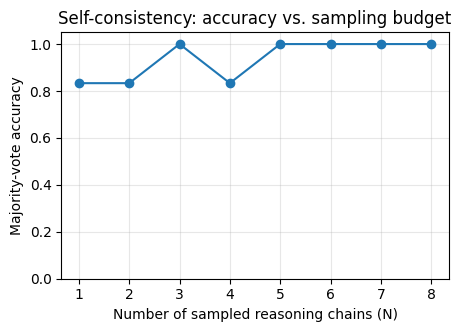

In [ ]:
# self-consistency accuracy vs. N, empirically.

N_MAX = 8
per_item_samples = []   # per_item_samples[i] = (list of predicted numbers, gold answer)

for item in EVAL_SET:
    gens = chat_generate(tokenizer, model, item["q"], COT_SYS,
                          n=N_MAX, temperature=0.8, max_new_tokens=400)
    preds = [extract_final_number(g) for g in gens]
    per_item_samples.append((preds, item["answer"]))

def self_consistency_acc(k):
    correct = 0
    for preds, gold in per_item_samples:
        subset = [p for p in preds[:k] if p is not None]
        if not subset:
            continue
        vote = Counter(subset).most_common(1)[0][0]
        correct += is_correct(vote, gold)
    return correct / len(per_item_samples)

sc_curve = [(k, self_consistency_acc(k)) for k in range(1, N_MAX + 1)]
for k, a in sc_curve:
    RESULTS[f"self_consistency_N{k}"] = [a]
    print(f"N={k}: acc={a:.2%}")

plt.figure(figsize=(5,3.2))
plt.plot(*zip(*sc_curve), marker="o")
plt.xlabel("Number of sampled reasoning chains (N)")
plt.ylabel("Majority-vote accuracy")
plt.title("Self-consistency: accuracy vs. sampling budget")
plt.ylim(0,1.05); plt.grid(alpha=.3); plt.show()

## 3. Least-to-Most Decomposition

Least-to-most prompting (Zhou et al. 2022) explicitly decomposes a hard problem $x$ into an ordered sequence of easier sub-problems $x_1, \dots, x_k$, solved one at a time, each conditioned on the answers to the previous ones:
$$P_\theta(y \mid x) \approx \prod_{i=1}^{k} P_\theta(y_i \mid x, y_{<i})$$
This trades one hard inference for $k$ easier, *dependent* ones.

**When this helps, and when it doesn't.** Success now requires *every* sub-step to be correct, so end-to-end success probability is the product $\prod_i (1-\varepsilon_i)$ of the per-step error rates. Decomposition only gives a net win when it reduces per-step difficulty by *more than* the number of new steps it introduces — roughly, the average per-step error needs to be smaller than (single-shot error) / $k$. Splitting a problem into many "easy-looking" steps is not automatically safer: errors compound multiplicatively across steps, so a decomposition with too many steps can end up *more* error-prone than solving the problem directly, even though each individual step looks trivial.

In [ ]:
# single-shot vs. explicit decomposition


MULTISTEP_Q = ("A store buys shirts at $12 each and sells them at a 45% markup. "
               "During a sale, the store discounts the sale price by 20%. "
               "If a customer buys 3 shirts during the sale, what is the total "
               "amount paid, rounded to the nearest cent?")
GOLD = round(3 * (12 * 1.45 * 0.8), 2)   # 41.76

single_shot = chat_generate(tokenizer, model, MULTISTEP_Q, COT_SYS,
                             temperature=0.0, max_new_tokens=400)[0]

DECOMP_SYS = ("Solve the problem by first listing the minimal ordered list of "
              "sub-questions needed, then answering them one by one using the "
              "previous answers, and finally give 'Final Answer: <number>'.")
decomposed = chat_generate(tokenizer, model, MULTISTEP_Q, DECOMP_SYS,
                            temperature=0.0, max_new_tokens=500)[0]

print("GOLD:", GOLD)
print("\n--- single-shot prediction:", extract_final_number(single_shot))
print("\n--- decomposed prediction:", extract_final_number(decomposed))

[transformers] Both `max_new_tokens` (=400) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=500) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


GOLD: 41.76

--- single-shot prediction: 49.2

--- decomposed prediction: 43.2


## 4. Verifier-Guided Reasoning: Best-of-N and Reward Models

Instead of voting, train or prompt a **verifier** $V(x, z, y) \to [0,1]$ that scores how likely a candidate solution is to be correct, and return $\arg\max_i V(x, z^{(i)}, y^{(i)})$ over $N$ sampled candidates — Best-of-N.

In [ ]:
# self-verification Best-of-N vs. plain


VERIFY_SYS = ("You will be shown a math problem and one proposed solution. "
              "Judge ONLY whether the final numeric answer is correct. "
              "Reply with ONLY 'YES' or 'NO'.")

def verifier_score(question, candidate_text):
    prompt = f"Problem: {question}\nProposed solution:\n{candidate_text}\n\nIs the final answer correct?"
    gen = chat_generate(tokenizer, model, prompt, VERIFY_SYS, temperature=0.0, max_new_tokens=4)[0]
    return 1.0 if "YES" in gen.upper() else 0.0

bo_n_correct, mv_correct = 0, 0
for (preds, gold), item in zip(per_item_samples, EVAL_SET):
    # re-generate texts (not just numbers) for verification; small N for speed
    gens = chat_generate(tokenizer, model, item["q"], COT_SYS, n=4, temperature=0.8, max_new_tokens=400)
    cand_preds = [extract_final_number(g) for g in gens]
    scores = [verifier_score(item["q"], g) for g in gens]
    if any(scores):
        best_idx = int(np.argmax(scores))
        bo_n_correct += is_correct(cand_preds[best_idx], gold)
    valid = [p for p in cand_preds if p is not None]
    if valid:
        vote = Counter(valid).most_common(1)[0][0]
        mv_correct += is_correct(vote, gold)

n_items = len(EVAL_SET)
print(f"Best-of-4 with self-verifier: {bo_n_correct}/{n_items} = {bo_n_correct/n_items:.2%}")
print(f"Majority vote (N=4):          {mv_correct}/{n_items} = {mv_correct/n_items:.2%}")
RESULTS["best_of_4_verifier"] = [bo_n_correct/n_items]
RESULTS["majority_vote_4"]    = [mv_correct/n_items]

[transformers] Both `max_new_tokens` (=400) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=4) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=4) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=4) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggi

Best-of-4 with self-verifier: 4/6 = 66.67%
Majority vote (N=4):          5/6 = 83.33%


## 5. Process vs. Outcome Reward: The Credit Assignment Problem

An **Outcome Reward Model (ORM)** scores only the final answer (correct / incorrect). A **Process Reward Model (PRM)** scores each intermediate reasoning step individually (Lightman et al. 2023, "Let's Verify Step by Step").

**Why outcome-only reward is a weak training signal for long chains.** Think of a chain as a sequence of step-correctness variables $c_1,\dots,c_k$, where the final answer is correct only if *every* step is correct. If a chain has $k$ steps, a single step's contribution to the final 0/1 outcome gets diluted by whether all the *other* $k-1$ steps also happened to be correct — the signal attributable to any one step shrinks roughly exponentially in $k$. A PRM instead scores each step directly, so its signal per step does not decay with chain length. This is why PRMs, despite being far more expensive to label (every step needs a judgment, not just the final answer), tend to give a much more sample-efficient training signal for improving multi-step reasoning.

[transformers] Both `max_new_tokens` (=300) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=6) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=6) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=6) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggi

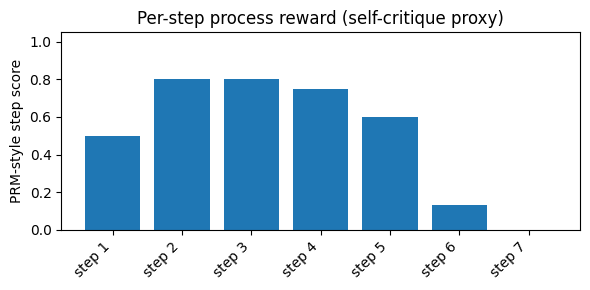

In [ ]:
# step-level self-critique as a proxy
# PRM, visualized per reasoning step.

STEP_CRITIQUE_SYS = ("You will see ONE step of a multi-step math solution, with the "
                      "context of the problem and prior steps. Rate ONLY this step's "
                      "correctness from 0 (definitely wrong) to 1 (definitely correct). "
                      "Reply with ONLY a decimal number.")

def split_into_steps(text):
    # crude split: sentences / newlines that look like discrete steps
    steps = [s.strip() for s in re.split(r"\n+|(?<=[.;])\s+", text) if len(s.strip()) > 3]
    return steps

def score_steps(question, steps):
    scores = []
    context = ""
    for s in steps:
        prompt = (f"Problem: {question}\nPrior steps:\n{context}\nStep to rate: {s}")
        gen = chat_generate(tokenizer, model, prompt, STEP_CRITIQUE_SYS,
                             temperature=0.0, max_new_tokens=6)[0]
        nums = re.findall(r"\d*\.?\d+", gen)
        scores.append(float(nums[0]) if nums else 0.5)
        context += s + "\n"
    return scores

demo_item = EVAL_SET[0]
demo_gen = chat_generate(tokenizer, model, demo_item["q"], COT_SYS, temperature=0.0, max_new_tokens=300)[0]
demo_steps = split_into_steps(demo_gen)[:8]
step_scores = score_steps(demo_item["q"], demo_steps)

plt.figure(figsize=(6,3))
plt.bar(range(len(step_scores)), step_scores)
plt.xticks(range(len(step_scores)), [f"step {i+1}" for i in range(len(step_scores))], rotation=45, ha="right")
plt.ylabel("PRM-style step score")
plt.ylim(0,1.05); plt.title("Per-step process reward (self-critique proxy)")
plt.tight_layout(); plt.show()

## 6. References

- Wei et al., *Chain-of-Thought Prompting Elicits Reasoning in Large Language Models*, 2022.
- Wang et al., *Self-Consistency Improves Chain of Thought Reasoning in Language Models*, 2022.
- Yao et al., *Tree of Thoughts: Deliberate Problem Solving with Large Language Models*, 2023.
- Zhou et al., *Least-to-Most Prompting Enables Complex Reasoning in Large Language Models*, 2022.
- Lightman et al., *Let's Verify Step by Step*, 2023.
- Zelikman et al., *STaR: Bootstrapping Reasoning With Reasoning*, 2022.
- Feng et al., *Towards Revealing the Mystery Behind Chain of Thought: A Theoretical Perspective*, 2023.
- Schulman et al., *Proximal Policy Optimization Algorithms*, 2017.
- Shao et al., *DeepSeekMath: Pushing the Limits of Mathematical Reasoning in Open Language Models* (GRPO), 2024.
- Cobbe et al., *Training Verifiers to Solve Math Word Problems* (GSM8K), 2021.